Saving Student_Projects.zip to Student_Projects (1).zip
replace CELOSIA ARGENTEA L/00ab26d4-71a6-4185-970f-e03166ad10ae.jpeg? [y]es, [n]o, [A]ll, [N]one, [r]ename: N
'CELOSIA ARGENTEA L'  'PURPLE CHLORIS'	'Student_Projects (1).zip'
'CROWFOOT GRASS'       sample_data	 Student_Projects.zip
Detected 3 classes: CELOSIA ARGENTEA L, CROWFOOT GRASS, PURPLE CHLORIS

Restructuring dataset...
  Class 'CELOSIA ARGENTEA L': 48 training images, 12 testing images.
  Class 'CROWFOOT GRASS': 48 training images, 12 testing images.
  Class 'PURPLE CHLORIS': 58 training images, 15 testing images.

Dataset restructured into 'structured_dataset' with 'train' and 'test' subdirectories.
Train directory: structured_dataset/train
Test directory: structured_dataset/test
Using Path: structured_dataset
Found 154 images belonging to 3 classes.
Found 39 images belonging to 3 classes.
Classes: {'CELOSIA ARGENTEA L': 0, 'CROWFOOT GRASS': 1, 'PURPLE CHLORIS': 2}
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1

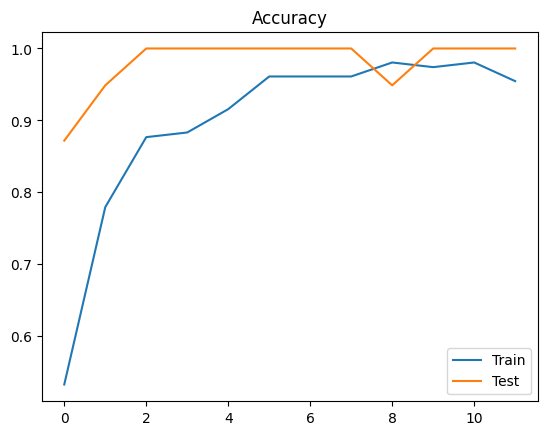

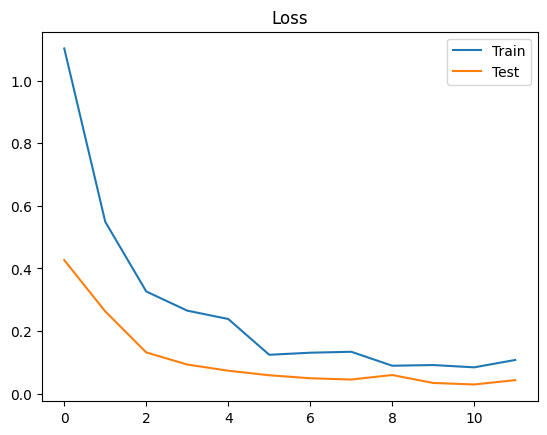

In [ ]:
# =========================
# STEP 1: Upload Dataset
# =========================

from google.colab import files
files.upload()   # Upload Student_Projects.zip

# =========================
# STEP 2: Extract Dataset
# =========================
!unzip -q Student_Projects.zip
!ls

# =========================
# STEP 3: Set Dataset Path and Restructure Data
# =========================
import os
import shutil
import random

# Define a root directory for the structured dataset
dataset_root = "structured_dataset"
train_dir = os.path.join(dataset_root, "train")
test_dir = os.path.join(dataset_root, "test")

# Ensure the root dataset directory exists
os.makedirs(train_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

# Detect class directories directly under /content/
# Filter out system directories/files
content_items = os.listdir("/content/")
potential_class_dirs = []
for item in content_items:
    full_path = os.path.join("/content/", item)
    if os.path.isdir(full_path) and not item.startswith('.') and item not in ['sample_data', dataset_root]:
        # Check if it contains image files to be sure it's a class folder
        # This is a heuristic; more robust would be to glob for image extensions
        if any(f.endswith(('.jpg', '.jpeg', '.png', '.gif')) for f in os.listdir(full_path)):
            potential_class_dirs.append(item)

if not potential_class_dirs:
    raise Exception("No class directories found after unzipping. Please check the zip file structure.")

class_names = potential_class_dirs
num_classes = len(class_names)
print(f"Detected {num_classes} classes: {', '.join(class_names)}")

print("\nRestructuring dataset...")
for class_name in class_names:
    src_class_path = os.path.join("/content", class_name)

    # Create class subdirectories in train and test
    os.makedirs(os.path.join(train_dir, class_name), exist_ok=True)
    os.makedirs(os.path.join(test_dir, class_name), exist_ok=True)

    images = [f for f in os.listdir(src_class_path) if os.path.isfile(os.path.join(src_class_path, f))]
    random.shuffle(images)

    # Split data (e.g., 80% train, 20% test)
    train_split_idx = int(0.8 * len(images))
    train_images = images[:train_split_idx]
    test_images = images[train_split_idx:]

    for img_name in train_images:
        shutil.copy(os.path.join(src_class_path, img_name), os.path.join(train_dir, class_name, img_name))
    for img_name in test_images:
        shutil.copy(os.path.join(src_class_path, img_name), os.path.join(test_dir, class_name, img_name))
    print(f"  Class '{class_name}': {len(train_images)} training images, {len(test_images)} testing images.")

print(f"\nDataset restructured into '{dataset_root}' with 'train' and 'test' subdirectories.")
print(f"Train directory: {train_dir}")
print(f"Test directory: {test_dir}")

# The base_path variable from the original code was not truly used beyond this block,
# but to keep variable consistency in case.
base_path = dataset_root

print("Using Path:", base_path)

# =========================
# STEP 4: Enable oneDNN
# =========================
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "1"

# =========================
# STEP 5: Import Libraries
# =========================
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import time

# =========================
# STEP 6: Data Generators
# =========================
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    # Changed class_mode to 'categorical' for multi-class classification
    class_mode='categorical'
)

test_data = test_gen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=32,
    # Changed class_mode to 'categorical' for multi-class classification
    class_mode='categorical'
)

print("Classes:", train_data.class_indices)

# =========================
# STEP 7: Strong Model (MobileNetV2)
# =========================
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    # Changed final Dense layer for multi-class classification
    tf.keras.layers.Dense(num_classes, activation='softmax') # Use num_classes and softmax
])

# =========================
# STEP 8: Compile
# =========================
model.compile(
    optimizer='adam',
    # Changed loss to 'categorical_crossentropy' for multi-class classification
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# =========================
# STEP 9: Train Model
# =========================
start = time.time()

history = model.fit(
    train_data,
    epochs=12,
    validation_data=test_data
)

training_time = time.time() - start

# =========================
# STEP 10: Evaluate
# =========================
loss, acc = model.evaluate(test_data)

print("\n===== FINAL OUTPUT =====")
print("Accuracy:", acc)
print("Training Time:", round(training_time,2), "seconds")

# =========================
# STEP 11: Graphs (IMPORTANT)
# =========================
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy')
plt.legend(['Train', 'Test'])
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss')
plt.legend(['Train', 'Test'])
plt.show()

# =========================
# STEP 12: Save Model
# =========================
model.save("student_model.h5")